In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Titanic dataset
df = pd.read_csv(
    r"C:\Users\user\Documents\AnalytycsLab week 4 (task 1 and 2)\Titanic Dataset(task 2)\Titanic-Dataset.csv"
)

# --- Basic overview ---
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nDataset info:")
df.info()
print("\nDuplicate rows:", df.duplicated().sum())
print("\nMissing values:\n", df.isnull().sum())
print("\nSummary statistics (numeric columns):\n", df.describe())
print("\nSurvival counts:\n", df["Survived"].value_counts())
print(f"Survival rate: {df['Survived'].mean():.1%}")

Shape: (891, 12)

Data types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

First 5 rows:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male 

C:\Users\user\AppData\Local\Temp\ipykernel_6604\1846372498.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Survived", ax=axes[0], palette=["salmon", "seagreen"])
C:\Users\user\AppData\Local\Temp\ipykernel_6604\1846372498.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Did not survive", "Survived"])


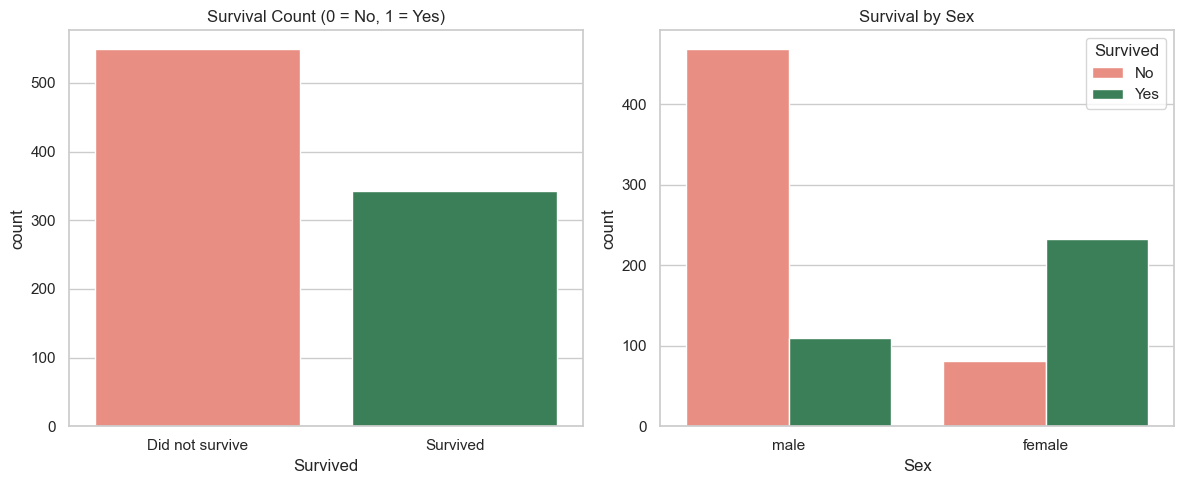

C:\Users\user\AppData\Local\Temp\ipykernel_6604\1846372498.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Survived", y="Age", ax=axes[2], palette=["salmon", "seagreen"])
C:\Users\user\AppData\Local\Temp\ipykernel_6604\1846372498.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(["Did not survive", "Survived"])


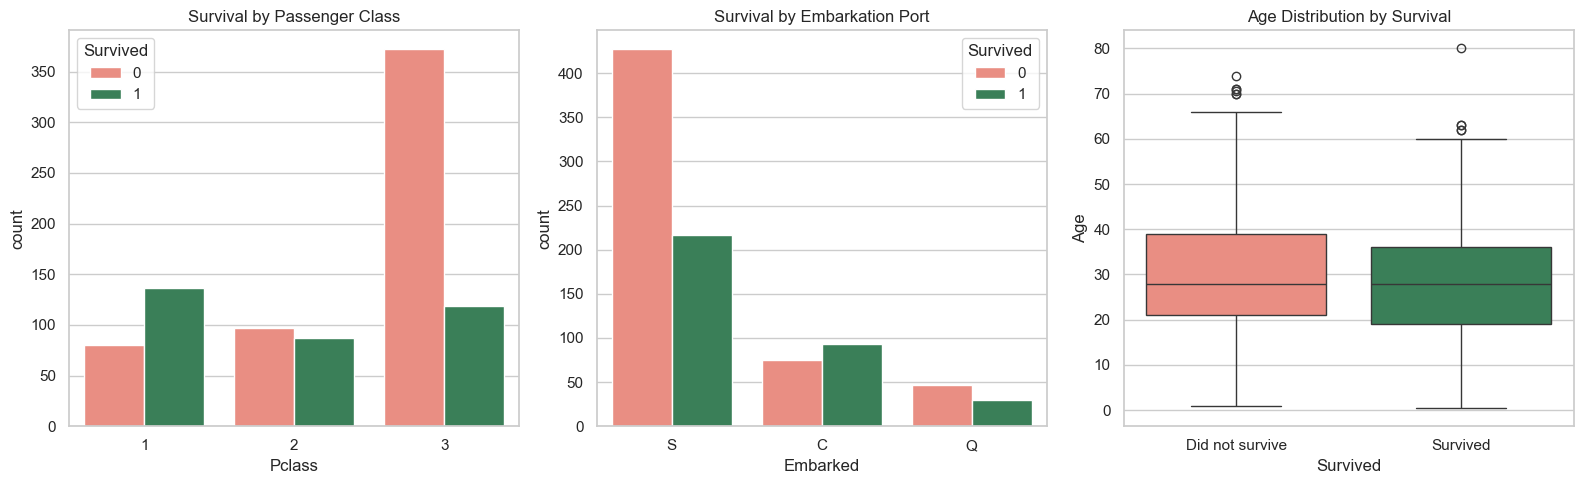

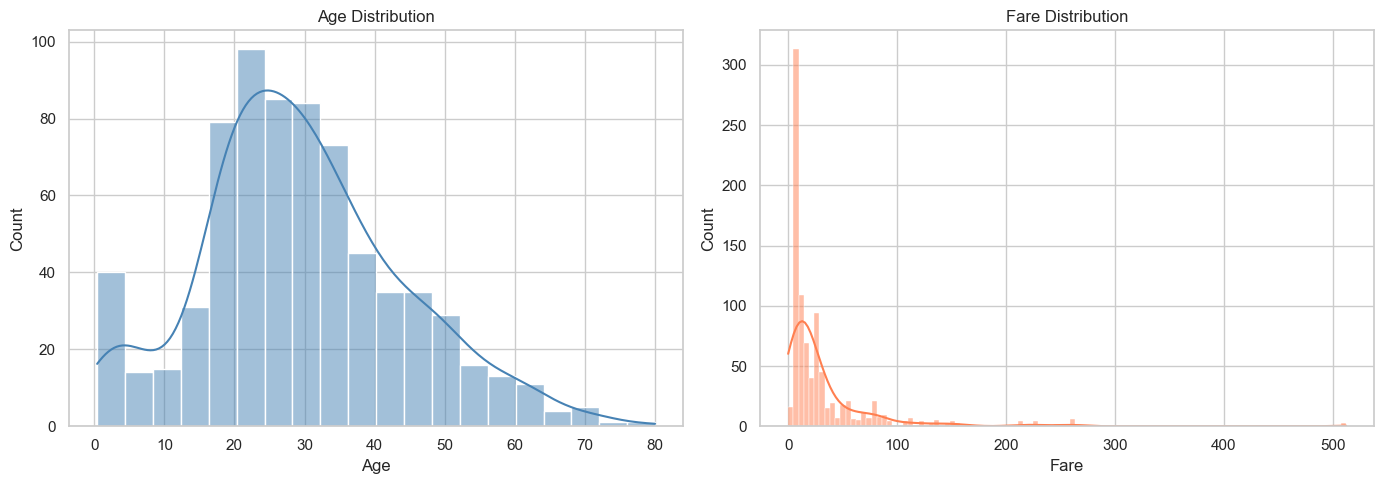

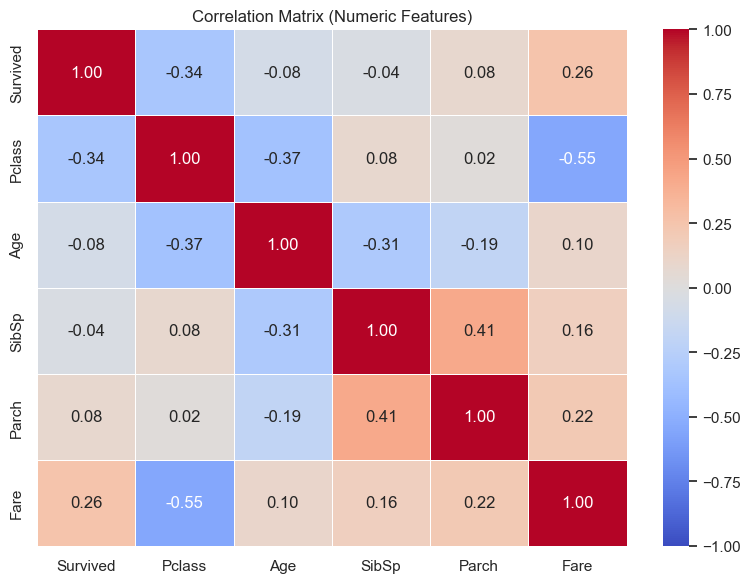

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Target variable — survival distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x="Survived", ax=axes[0], palette=["salmon", "seagreen"])
axes[0].set_title("Survival Count (0 = No, 1 = Yes)")
axes[0].set_xticklabels(["Did not survive", "Survived"])

sns.countplot(data=df, x="Sex", hue="Survived", ax=axes[1], palette=["salmon", "seagreen"])
axes[1].set_title("Survival by Sex")
axes[1].legend(title="Survived", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

# 2. Survival rate by key features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(data=df, x="Pclass", hue="Survived", ax=axes[0], palette=["salmon", "seagreen"])
axes[0].set_title("Survival by Passenger Class")

sns.countplot(data=df, x="Embarked", hue="Survived", ax=axes[1], palette=["salmon", "seagreen"])
axes[1].set_title("Survival by Embarkation Port")

sns.boxplot(data=df, x="Survived", y="Age", ax=axes[2], palette=["salmon", "seagreen"])
axes[2].set_title("Age Distribution by Survival")
axes[2].set_xticklabels(["Did not survive", "Survived"])
plt.tight_layout()
plt.show()

# 3. Age and Fare distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Age"].dropna(), kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Age Distribution")

sns.histplot(df["Fare"], kde=True, ax=axes[1], color="coral")
axes[1].set_title("Fare Distribution")
plt.tight_layout()
plt.show()

# 4. Correlation heatmap (numeric features)
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_6604\3117364102.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, palette="Oranges_r")


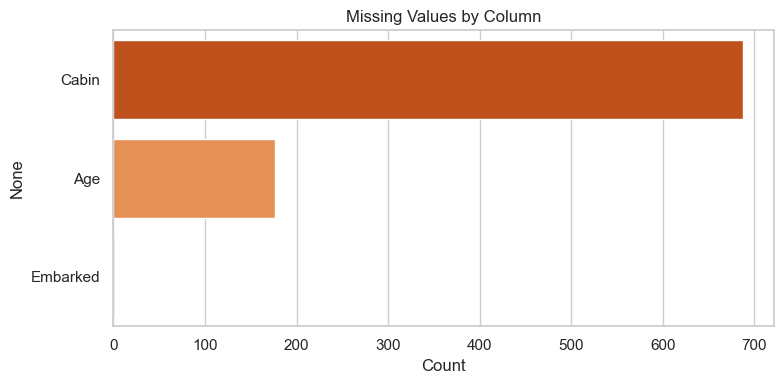


Survival rate by Sex:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

Survival rate by Pclass:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

Survival rate by Embarked:
Embarked
C    0.554
Q    0.390
S    0.337
Name: Survived, dtype: float64


In [3]:
# 5. Missing values visualisation
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=missing.values, y=missing.index, palette="Oranges_r")
plt.title("Missing Values by Column")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

# Survival rate breakdown
for col in ["Sex", "Pclass", "Embarked"]:
    print(f"\nSurvival rate by {col}:")
    print(df.groupby(col)["Survived"].mean().round(3))

In [4]:
# Key EDA takeaways
print("=== EDA Summary ===")
print(f"• {df.shape[0]} passengers, {df.shape[1]} columns")
print(f"• Overall survival rate: {df['Survived'].mean():.1%}")
print(f"• Missing values: Age ({df['Age'].isnull().sum()}), Cabin ({df['Cabin'].isnull().sum()}), Embarked ({df['Embarked'].isnull().sum()})")
print(f"• Women survived far more often than men")
print(f"• 1st class passengers had higher survival rates than 2nd/3rd class")
print(f"• Pclass and Sex are strong predictors of survival")

=== EDA Summary ===
• 891 passengers, 12 columns
• Overall survival rate: 38.4%
• Missing values: Age (177), Cabin (687), Embarked (2)
• Women survived far more often than men
• 1st class passengers had higher survival rates than 2nd/3rd class
• Pclass and Sex are strong predictors of survival


# Machine Learning — Titanic Survival Prediction

Steps: preprocess features → train/test split → train classifiers → evaluate and compare performance.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
)

# --- Step 1: Feature engineering and preprocessing ---
df_ml = df.copy()

# Fill missing Age with median by Sex and Pclass (more accurate than global median)
df_ml["Age"] = df_ml.groupby(["Sex", "Pclass"])["Age"].transform(
    lambda x: x.fillna(x.median())
)
df_ml["Age"] = df_ml["Age"].fillna(df_ml["Age"].median())

# Fill missing Embarked with mode
df_ml["Embarked"] = df_ml["Embarked"].fillna(df_ml["Embarked"].mode()[0])

# Create useful features
df_ml["FamilySize"] = df_ml["SibSp"] + df_ml["Parch"] + 1
df_ml["IsAlone"] = (df_ml["FamilySize"] == 1).astype(int)
df_ml["HasCabin"] = df_ml["Cabin"].notna().astype(int)

# Select features for modelling (drop high-cardinality / ID columns)
feature_cols = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "FamilySize", "IsAlone", "HasCabin"]
X = df_ml[feature_cols]
y = df_ml["Survived"]

# One-hot encode categoricals
X_encoded = pd.get_dummies(X, columns=["Sex", "Embarked"], drop_first=False)

print("Feature matrix shape:", X_encoded.shape)
print("Missing values after preprocessing:", X_encoded.isnull().sum().sum())
print("\nEncoded feature columns:\n", list(X_encoded.columns))

Feature matrix shape: (891, 13)
Missing values after preprocessing: 0

Encoded feature columns:
 ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


In [6]:
# --- Step 2: Train / test split (80% train, 20% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Train survival rate: {y_train.mean():.1%}")
print(f"Test survival rate:  {y_test.mean():.1%}")

Training set: 712 samples
Test set:     179 samples
Train survival rate: 38.3%
Test survival rate:  38.5%


In [7]:
# --- Step 3: Build and train models ---
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone", "HasCabin"]

preprocessor = ColumnTransformer(
    transformers=[("scaler", StandardScaler(), numeric_features)],
    remainder="passthrough",
)

models = {
    "Logistic Regression": Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42)),
    ]),
}

results = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_prob

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    }

results_df = pd.DataFrame(results).T.round(3)
print("Model Performance on Test Set:\n")
print(results_df)

best_model = results_df["Accuracy"].idxmax()
print(f"\nBest model (by Accuracy): {best_model}")

Model Performance on Test Set:

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     0.804      0.774   0.696     0.733    0.845
Random Forest           0.782      0.734   0.681     0.707    0.823

Best model (by Accuracy): Logistic Regression


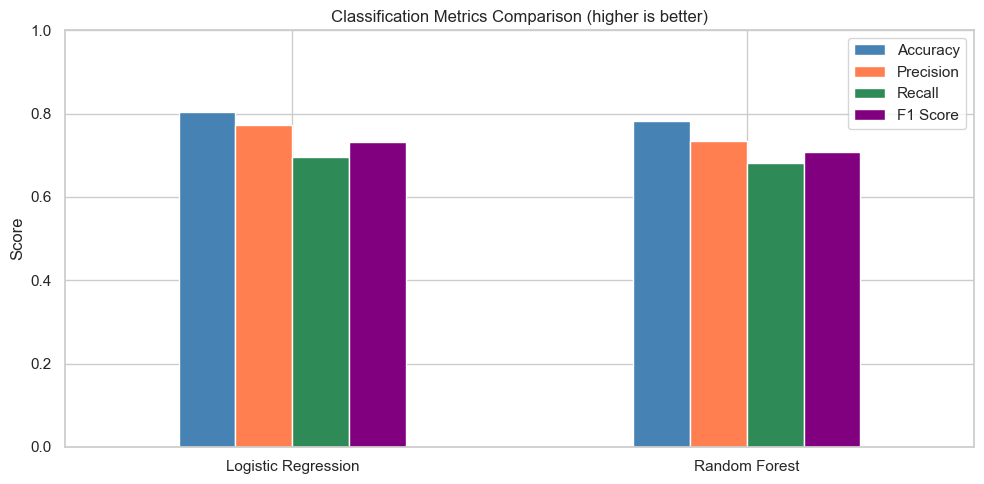

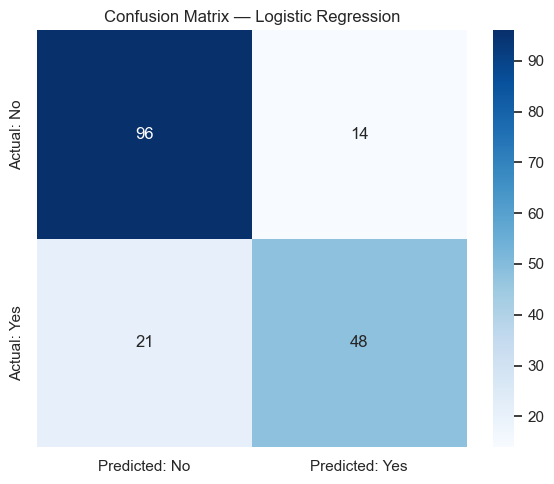


Classification Report — Logistic Regression:

                 precision    recall  f1-score   support

Did not survive       0.82      0.87      0.85       110
       Survived       0.77      0.70      0.73        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



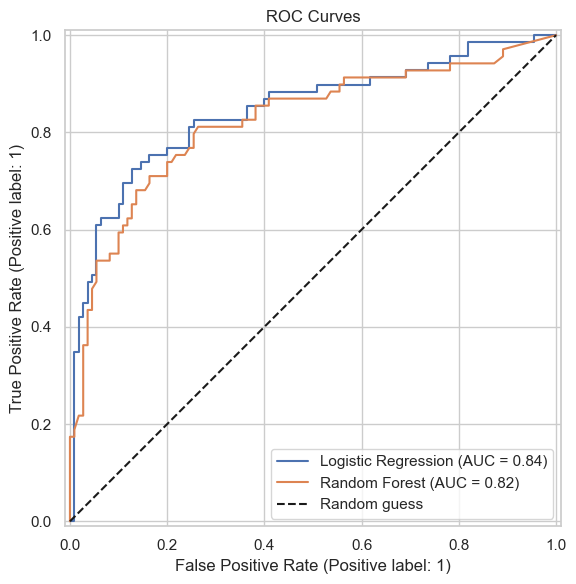

In [8]:
# --- Step 4: Visualise model performance ---

# 4a. Compare metrics across models
fig, ax = plt.subplots(figsize=(10, 5))
results_df[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", ax=ax, color=["steelblue", "coral", "seagreen", "purple"]
)
ax.set_title("Classification Metrics Comparison (higher is better)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

# 4b. Confusion matrix (best model)
y_pred_best = predictions[best_model]
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted: No", "Predicted: Yes"],
    yticklabels=["Actual: No", "Actual: Yes"],
)
plt.title(f"Confusion Matrix — {best_model}")
plt.tight_layout()
plt.show()

print(f"\nClassification Report — {best_model}:\n")
print(classification_report(y_test, y_pred_best, target_names=["Did not survive", "Survived"]))

# 4c. ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for name in models:
    RocCurveDisplay.from_predictions(y_test, probabilities[name], name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random guess")
ax.set_title("ROC Curves")
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_6604\1852960678.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette="viridis")


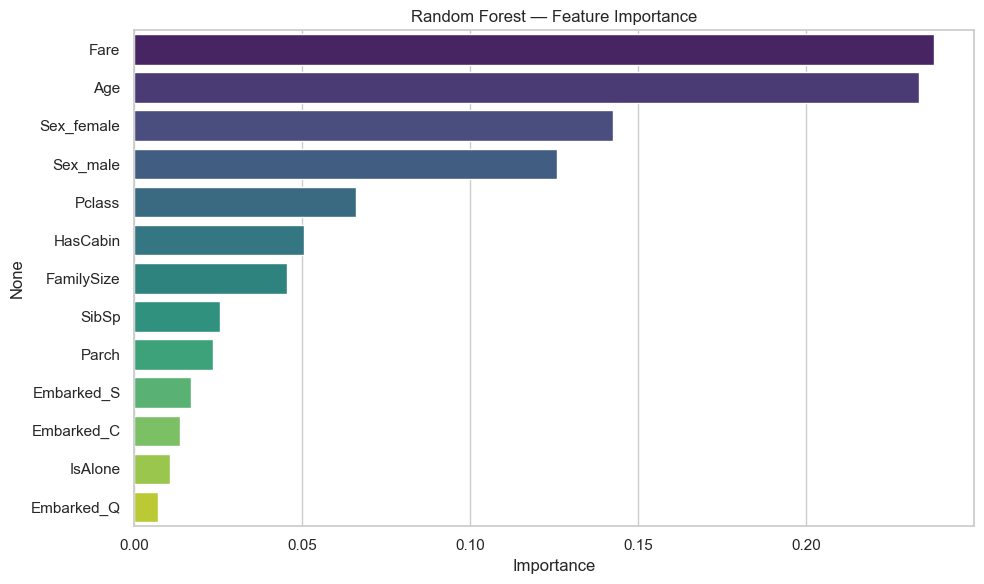

Top 5 most important features:
 Fare          0.237991
Age           0.233648
Sex_female    0.142450
Sex_male      0.125839
Pclass        0.066056
dtype: float64


In [9]:
# --- Step 5: Feature importance (Random Forest) ---
rf_model = models["Random Forest"].named_steps["model"]
feature_names = numeric_features + [c for c in X_encoded.columns if c not in numeric_features]

importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index, palette="viridis")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 5 most important features:\n", importance.head())

In [10]:
# --- Step 6: Sample prediction on a new passenger ---
sample = pd.DataFrame([{
    "Pclass": 3,
    "Sex": "female",
    "Age": 25,
    "SibSp": 0,
    "Parch": 0,
    "Fare": 7.25,
    "Embarked": "S",
    "FamilySize": 1,
    "IsAlone": 1,
    "HasCabin": 0,
}])

sample_encoded = pd.get_dummies(sample, columns=["Sex", "Embarked"], drop_first=False)
sample_encoded = sample_encoded.reindex(columns=X_encoded.columns, fill_value=0)

best_pipeline = models[best_model]
survival_prob = best_pipeline.predict_proba(sample_encoded)[0, 1]
survival_pred = best_pipeline.predict(sample_encoded)[0]

print("Sample passenger details:")
print(sample.T)
print(f"\nPredicted survival ({best_model}): {'Yes' if survival_pred == 1 else 'No'}")
print(f"Probability of survival: {survival_prob:.1%}")

Sample passenger details:
                 0
Pclass           3
Sex         female
Age             25
SibSp            0
Parch            0
Fare          7.25
Embarked         S
FamilySize       1
IsAlone          1
HasCabin         0

Predicted survival (Logistic Regression): Yes
Probability of survival: 57.4%


In [11]:
# --- ML Summary ---
print("=== Machine Learning Summary ===")
print(f"• Task: Binary classification (predict Survived: 0 or 1)")
print(f"• Features used: {X_encoded.shape[1]} (after encoding and feature engineering)")
print(f"• Preprocessing: filled missing Age/Embarked, created FamilySize, IsAlone, HasCabin")
print(f"• Train/test split: 80% / 20% (stratified)")
print(f"• Models trained: Logistic Regression, Random Forest")
print(f"• Best model: {best_model} (Accuracy = {results_df.loc[best_model, 'Accuracy']:.1%}, ROC-AUC = {results_df.loc[best_model, 'ROC-AUC']:.3f})")
print(f"• Sex and passenger class were the strongest survival predictors in EDA and feature importance")

=== Machine Learning Summary ===
• Task: Binary classification (predict Survived: 0 or 1)
• Features used: 13 (after encoding and feature engineering)
• Preprocessing: filled missing Age/Embarked, created FamilySize, IsAlone, HasCabin
• Train/test split: 80% / 20% (stratified)
• Models trained: Logistic Regression, Random Forest
• Best model: Logistic Regression (Accuracy = 80.4%, ROC-AUC = 0.845)
• Sex and passenger class were the strongest survival predictors in EDA and feature importance
